## Synthetic ICM Example

In this example, we will use the synthetic fields to generate mock ICM profiles.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()
# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


(<CalculationMode.USE_GPU: 1>,)

Setup information for the mock ICM profile. In this example, we go straight to generating the 2D observation, rather than generating a 3D field and projecting it (which would be the more realistic scenario).

In [2]:
## COMA X-RAY BETA PROFILE
I0 = 4e-3
rc = (245.*u.kpc).value
beta = 0.6

## ASSUMED (CONSTANT) TEMPERATURE
Te = 1e8

## Resolution parameters
N = 1024
D = 2
grid_dims = (N,)*D

## Set physical scale of this mock cluster
L = (500.*u.kpc).value
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = L

dx, dk = geometry.get_dxdk(grid_dims)
dx = dx[0]
dk = dk[0]

Generate the (2D) large-scale unperturbed cluster profile

In [3]:
## Generate mean Beta profile
grid = np.indices(grid_dims)
pos = [n//2-1 for n in grid_dims]
r = np.linalg.norm([grid[i,...] - pos[i] for i in range(len(grid_dims))], axis=0)*dx
ym = I0 / ((1. + (r/rc)**2.)**(3.*beta-0.5))
_r, ym_avg, _ = binning.bin_data(r, ym, np.nanmean)
_r, ym_std, _ = binning.bin_data(r, ym, np.nanstd)

(10, 500)

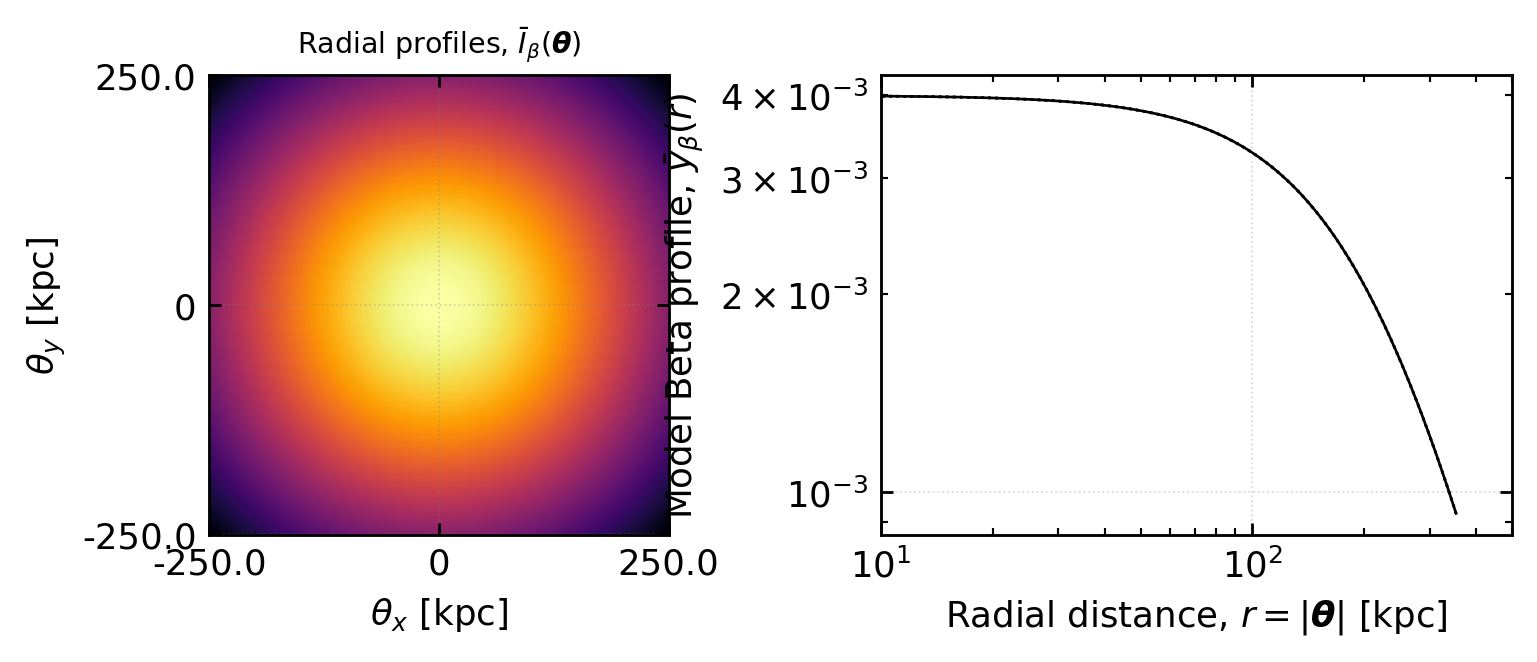

In [4]:
## Plot mean beta profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)
ax[0].imshow(ym, origin='lower', interpolation='none', cmap='inferno', norm=mpl.colors.LogNorm())
ax[1].plot(_r, ym_avg, linestyle='-', color='black', linewidth=0.75)
ax[1].plot(_r, ym_avg-ym_std, linestyle=':', color='black', linewidth=0.75)
ax[1].plot(_r, ym_avg+ym_std, linestyle=':', color='black', linewidth=0.75)
pretty_axes(ax[0])
pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Radial profiles, $\bar{I}_{\beta}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{\theta}|$ [kpc]')
ax[1].set_ylabel(r'Model Beta profile, $\bar{y}_{\beta}(r)$')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((10, 500))

Generate the (turbulence) fluctuations.

Given the (expected) dynamics of ICM turbulence, The synthetic isotropic turbulence field is modulated by the unperturbed cluster profile.

In [5]:
from kea.simulator import make_field
## Make model for fluctuations
# Effective injection scale and effective dissipation scale
ki, kd = (2.*dk, 50.*dk)
# What we want the value to be at the peak of the amplitude spectrum (approximately)
p = 0.2
# Modal/angle-averaged spectrum powerlaw
alpha = 8./3.
## Generate fluctuations
yf = make_field(grid_dims,
                spectrum_kwargs={'powerlaw': -alpha, 'break_1': ki, 'break_2': kd, 'amplitude': p**2*dk**3},
                spectrum_function='powerlaw_with_exponentials',
                seed=1, normalize_output=False)
yf = ym*yf

/home/mark.bishop/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark.bishop/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in divide
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark.bishop/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: invalid value encountered in multiply
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)


-0.0022441648990458047 0.0020033788923434935 -5.403286083804735e-06 0.00046768363787454375


Text(0.5, 1.0, '$\\delta I_\\mathrm{X}(\\boldsymbol{\\theta})$')

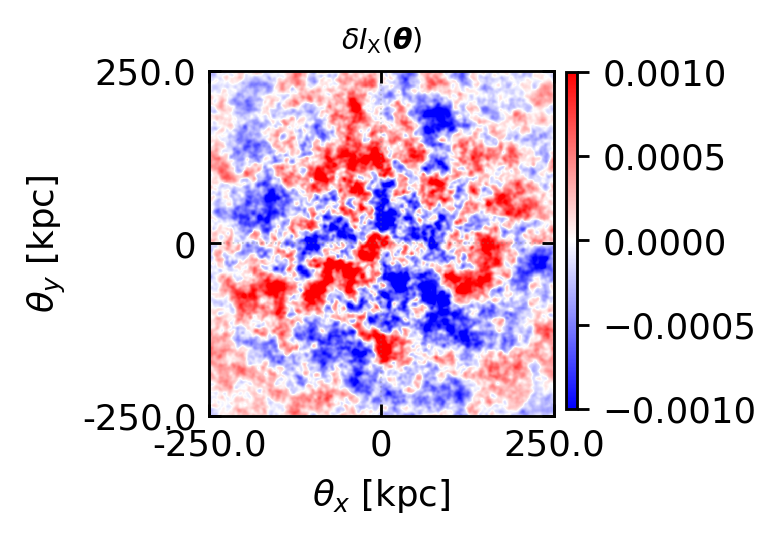

In [11]:
## Plot the modulated fluctuation field
fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=256)
_plt_field = yf
print(np.min(_plt_field), np.max(_plt_field), np.mean(_plt_field), np.std(_plt_field))
im = ax.imshow(_plt_field, interpolation='none', origin='lower', cmap='bwr', vmin=-1e-3, vmax=1e-3)
pretty_axes(ax)
ax.set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_ylabel(r'$\theta_y$ [kpc]')
ax.set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_xlabel(r'$\theta_x$ [kpc]')
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.925, 0.125, 0.025, 0.7525])
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
ax.set_title(r'$\delta I_\mathrm{X}(\boldsymbol{\theta})$', fontsize=8.)

Now make the total observation by adding the unperturbed field to the modulated fluctuation field:

In [7]:
## Make observed field
yobs = ym + yf
## Apply Poisson noise
from kea.simulator import apply_poisson
noisy_image = apply_poisson(yobs, target_SNR=15.)
## Project and radial average
_r, yobs_avg, _ = binning.bin_data(r, yobs, np.nanmean)
_r, yobs_std, _ = binning.bin_data(r, yobs, np.nanstd)

and plot the profiles:

(10, 500)

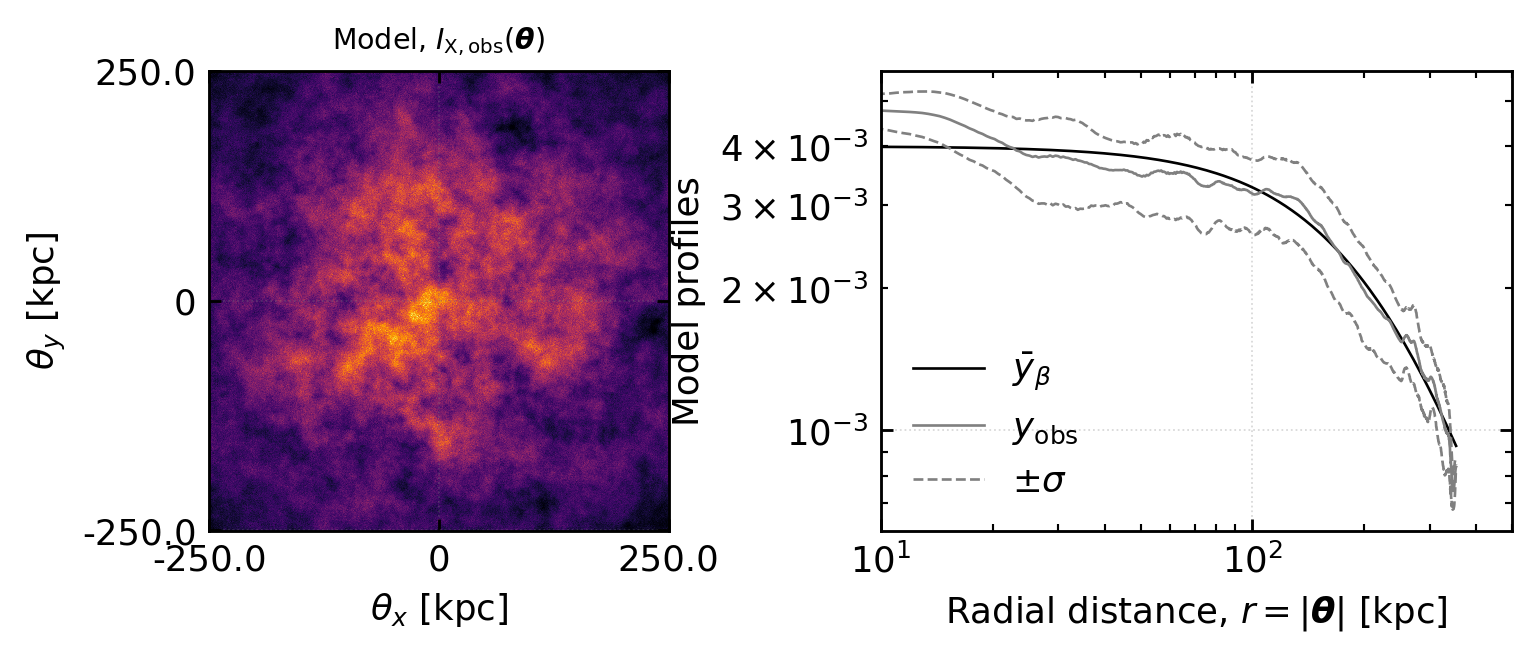

In [8]:
## Plot mean profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)

ax[0].imshow(noisy_image, origin='lower', interpolation='none', cmap='inferno')#, norm=mpl.colors.LogNorm())
ax[1].plot(_r, ym_avg, linestyle='-', color='black', linewidth=0.75, label=r'$\bar{y}_{\beta}$')
ax[1].plot(_r, yobs_avg, linestyle='-', color='gray', linewidth=0.75, label=r'$y_{\mathrm{obs}}$')
ax[1].plot(_r, yobs_avg-yobs_std, linestyle='--', color='gray', linewidth=0.75, label=r'$\pm \sigma$')
ax[1].plot(_r, yobs_avg+yobs_std, linestyle='--', color='gray', linewidth=0.75)

# ax[1].plot(_r, noise_avg, linestyle='-', color='blue', linewidth=0.75, label=r'$y_{\mathrm{obs}}$')

ax[1].legend(fancybox=False, frameon=False)
pretty_axes(ax[0])
pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Model, $I_{\mathrm{X},\mathrm{obs}}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{\theta}|$ [kpc]')
ax[1].set_ylabel(r'Model profiles')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((10, 500))

Now estimate the (amplitude) spectrum of the fluctuations. We see that the fluctuations have an amplitude of ~0.2 and the large wavenumbers are dominated by the noise floor.

Text(0.5, 0, 'Wavenumber [kpc$^{-1}$]')

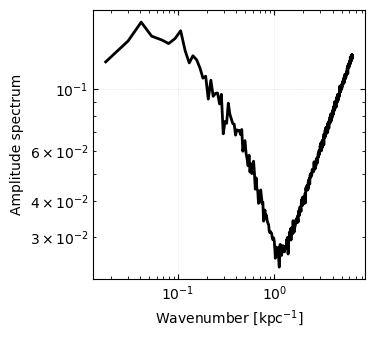

In [9]:
# Calculate spectrum
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum, transform_spectrum
kvec, modal_spectrum = fourier_modal_spectrum(noisy_image)
kp, fekp, bin_widths = bin_spectrum(kvec, modal_spectrum, 'integrated')
# Calculate the amplitude spectrum -- commonly used in ICM analyses
k, amp = transform_spectrum(kp, fekp, 3, 'integrated', 'amplitude', grid_dims, bin_widths=bin_widths, is_centered=True)
## Plot spectrum
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(k, amp, linewidth=2., linestyle='-', color='black')
ax.set_yscale('log')
ax.set_xscale('log')
pretty_axes(ax)
ax.set_ylabel('Amplitude spectrum')
ax.set_xlabel('Wavenumber [kpc$^{-1}$]')